<a href="https://colab.research.google.com/github/SoulWare0265/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?:
- **Se puede observar que en el dataframe de Users, presentan columna de city, se presenta que tiene valores faltantes del 11.7%, en el caso de churn_date presenta más del 80%, pero este porcentaje son de los usuarios que aún siguen activos, no pienso tocar o mover esta columna para no presentar anomalias y destruir la información**
- **Se puede observar que en el dataframe de Usage, presentan tanto las columnas duration y length entre el 45% a 55%, mientras que en date se presenta el 0.1%. Pero al validar estos valores nulos sucede igual que en churn_date los valores nulos de duration se ven reflejados en el  texto ya que si fuera nulo se vería representado como una llamada perdida, en length sucede todo lo contrario con el type texto no se encuentran nulos, pero si al validar una duration**
- Indica qué harías: ¿imputar, eliminar, ignorar?:
- **Al revisar el dataframe y entender el mercado de telecomunicaciones, solamente haré imputaciones a los datos en donde se encuentren faltantes o que estén erroneos, en el caso de churn_date no le haré ninguna modificación para alterar la columna. Ya que si se encuentra nulo quiere decir que el usuario no ha cancelado el plan**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[["user_id", "age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
users[["user_id", "age"]].le(0).sum()

user_id     0
age        55
dtype: int64

- La columna `user_id` No se encuentran valores menores a 0 en el ID del usuario.
- La columna `age` Se encuentran valores menores a 0 **-999, para ser exactos**

In [ ]:
# explorar columnas numéricas de usage
usage[["id", "user_id"]].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`Son columnas diferentes, el `id` hace referencia lo que hizo el usuario, ya sea una llamada o un mensaje de texto, en cuanto al `user_id` se puede observar el ID del usuario correspondiente que hizo dicho consumo de su plan

In [ ]:
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` ...
- La columna `plan` ...

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` se puede observar que esta columna se presentan los tipos de consumos que el usuario uso en respectivas ocasiones ya sea una llamada o un SMS


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
  
  
- **Los valores invalidos se pudo observar tanto en la edad de los usuarios como `-999` o de las ciudades `?`, la acción que llevaría a cabo es la imputación de estos valores ya sea cambiando a Nulos o renombrar dicho dato**

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
date_drop_cols = ["reg_date"]

for col in date_drop_cols:
    users[col] = pd.to_datetime(users[col], errors="coerce")
    users = users.dropna(subset=[col]).reset_index(drop=True)

In [ ]:
# Convertir a fecha la columna `date` de usage
date_drop_cols = ["date"]

for col in date_drop_cols:
    usage[col] = pd.to_datetime(usage[col], errors="coerce")
    usage = usage.dropna(subset=[col]).reset_index(drop=True)

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

**En `reg_date`, se puede validar que hay fechas del 2022 al 2024, pero hay resultados en donde aparece una fecha imposible que es 2026 y representa el 1% de los datos registrados**

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage["date"].isna().sum())
usage["date"].dt.year.value_counts().sort_index()

0


2024    39950
Name: date, dtype: int64

**En `date`, se observa que es la fecha en la cual el usuario realizo una llamada o un SMS.**  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- **Si, aparecen años imposibles en las cuales no han transcurrido por el momento, se va hacer la respectiva corrección poniendo que estás son Nulos**

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
print("\nValores Ausentes de Age")
print(users["age"].value_counts().sort_index())
print(users["age"].describe())


Valores Ausentes de Age
-999    55
 18     65
 19     65
 20     64
 21     57
        ..
 75     62
 76     61
 77     58
 78     79
 79     59
Name: age, Length: 63, dtype: int64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:
# Reemplazar -999 por la mediana de age
def reemplazar_ausentes(users, sentinels, num_col):
    for col in num_col:
        users[col] = users[col].replace(sentinels, pd.NA)
    return users
def rellenar_ausentes(users, cols):
    for col in cols:
        users[col] = pd.to_numeric(users[col], errors="coerce")
        users[col].fillna(users[col].median(), inplace=True)
    return users
def limpiar_users(users):
    valores_erroneos = [-999, 999, 0, -1]
    columna_num = ["age"]

    users = reemplazar_ausentes(users, valores_erroneos, columna_num)
    users = rellenar_ausentes(users, columna_num)
    return users
users = limpiar_users(users)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
print("\nValores Ausentes de City")
print(users["city"].value_counts().sort_index())
print(users["city"].describe())


Valores Ausentes de City
?            96
Bogotá      808
CDMX        730
Cali        424
GDL         450
MTY         407
Medellín    616
Name: city, dtype: int64
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object


In [ ]:
# Reemplazar ? por NA en city
def reemplazar_ausentes(users, sentinels, obj_col):
    for col in obj_col:
        users[col] = users[col].str.strip().replace(sentinels, pd.NA)
    return users
def rellenar_ausentes(users, cols):
    for col in cols:
        users[col] = users[col].fillna("Unknown")
    return users
def limpiar_users(users):
    valores_erroneos = ["?", "", "<NA>", "nan"]
    columna_obj = ["city"]

    users = reemplazar_ausentes(users, valores_erroneos, columna_obj)
    users = rellenar_ausentes(users, columna_obj)
    return users
users = limpiar_users(users)
# Verificar cambios
users["city"].isna().sum()
print(users["city"].value_counts().sort_index())

Bogotá      808
CDMX        730
Cali        424
GDL         450
MTY         407
Medellín    616
Unknown     565
Name: city, dtype: int64


In [ ]:
def reemplazar_fecha(users, sentinels, date_col):
    for col in date_col:
        users[col] = users[col].replace(sentinels, pd.NaT)
    return users

def rellenar_ausentes(users, cols):
    for col in cols:
        users[col] = pd.to_datetime(users[col], errors='coerce')
        users.loc[users[col].dt.year == 2026, col] = pd.NaT
    return users

def limpiar_users(users):
    año_erroneo = [2026]
    columna_fecha = ["reg_date"]

    users = reemplazar_fecha(users, año_erroneo, columna_fecha)
    users = rellenar_ausentes(users, columna_fecha)

    return users
users = limpiar_users(users)

#Verificar Cambios
print(users["reg_date"].dt.year.value_counts(dropna=False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


In [ ]:
print(users["reg_date"].dt.year.astype("Int64").value_counts(dropna=False))

2024    1330
2023    1316
2022    1314
NaN       40
Name: reg_date, dtype: Int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999275
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.999329
text    0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Se confirma que los valores nulos en duration y length son MAR (Missing At Random), ya que su ausencia depende totalmente de la columna type.**
- **Las filas de tipo 'text' tienen nulos en duration porque un mensaje SMS no tiene una duración medible en tiempo.**
- **Las filas de tipo 'call' tienen nulos en length porque una llamada no contiene caracteres de texto.**

**Dado que estos nulos son lógicos y representan la naturaleza del servicio, se decide dejarlos como nulos para no sesgar futuros cálculos de promedios por tipo de servicio.**

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text":"sum",
    "is_call":"sum",
    "duration":"sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on = ["user_id"], how = "inner")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
print(user_profile[["user_id","age", "cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe())


            user_id          age  cant_mensajes  cant_llamadas  \
count   3999.000000  3999.000000    3999.000000    3999.000000   
mean   11999.729432    48.138285       5.518380       4.471618   
std     1154.898108    17.691541       2.358046       2.142878   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.500000    33.000000       4.000000       3.000000   
50%    12000.000000    48.000000       5.000000       4.000000   
75%    12999.500000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.288867  
std               18.161719  
min                0.000000  
25%               11.085000  
50%               19.770000  
75%               31.355000  
max              155.690000  


In [ ]:
# Distribución porcentual del tipo de plan
print(user_profile["plan"].value_counts(normalize=True))

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

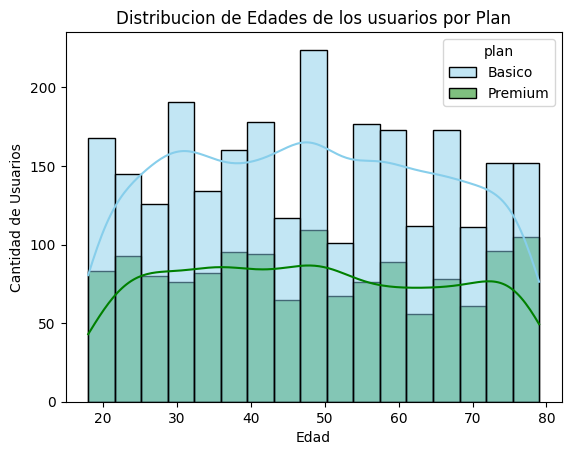

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
            x="age",
            hue="plan",
            palette=["skyblue", "green"],
            kde=True)
plt.title("Distribucion de Edades de los usuarios por Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
- Distribución uniforme, no se observa un factor determinante a la hora de elegir un plan, tanto jovenes como adultos usan ambos servicios.
- El plan básico es el más popular entre los usuarios y los rangos de edad. Esto es normal en el servicio de telecomunicaciones.
- El pico del plan básico se observa entre los usuarios de 50 años, mientras en el premium se observa leves picos entre los usuarios de 45 a 50 años y usuarios de 75 a 80 años

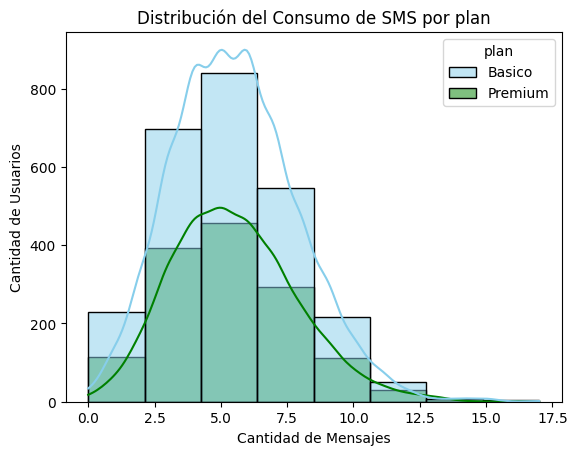

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,
            bins=8,
            x="cant_mensajes",
            hue="plan",
            palette=["skyblue", "green"],
            kde=True)
plt.title("Distribución del Consumo de SMS por plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
- Se sigue presentando una distribucion sesgada a la derecha, donde muy pocos usuarios superan enviar 12 mensajes.
- Hay un pico en ambos planes al enviar 5 mensajes y en su mayoria envía mensajes entre 2.5 a 7.5 mensajes
- Se observa que cada plan sigue su forma pero con menos volumen para el Plan Premium

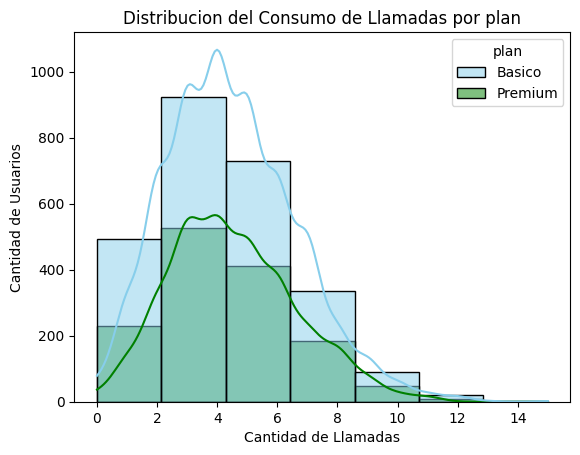

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,
            bins=7,
            x="cant_llamadas",
            hue="plan",
            palette=["skyblue", "green"],
            kde=True)
plt.title("Distribucion del Consumo de Llamadas por plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
- Distribución sesgada a la derecha, donde pocos usuarios realizan llamadas 10 a 12 veces.
- Se encuentra un pico en donde los usuarios realizan de 2 a 4 llamadas y de parte del Plan Básico sigue subiendo **más de 1000 usuarios**
- Ambos planes siguen la misma forma resaltando menos volumen en el Plan Premium

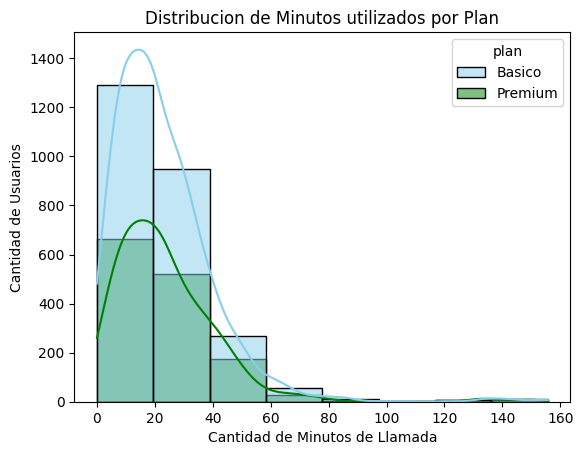

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,
            bins=8,
            x="cant_minutos_llamada",
            hue="plan",
            palette=["skyblue", "green"],
            kde=True)
plt.title("Distribucion de Minutos utilizados por Plan")
plt.xlabel("Cantidad de Minutos de Llamada")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
- Distribución sesgada a la derecha donde pocos usuarios realizan llamadas largas más de 1 hora
- Los picos se encuentran bastantes altos entre los 0 a 20 minutos superando por mucho al Plán Básico **más de 2000 usuarios**
- Ambos planes siguen la misma forma resaltando mucho menos volumen en el Plan Premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

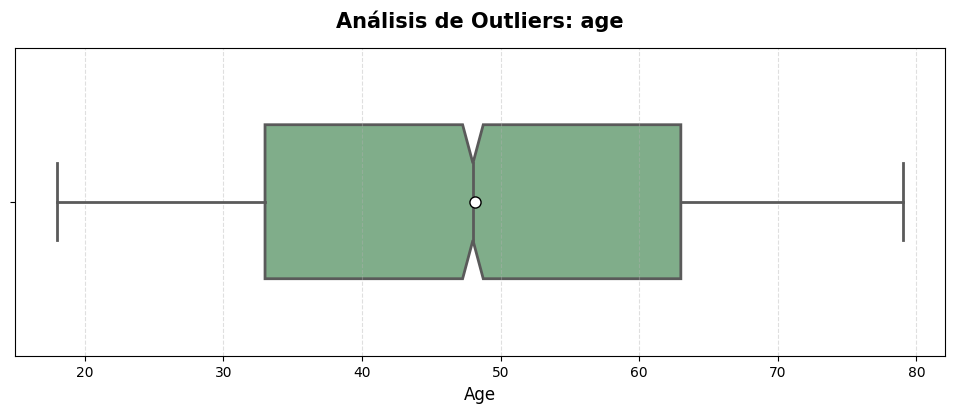

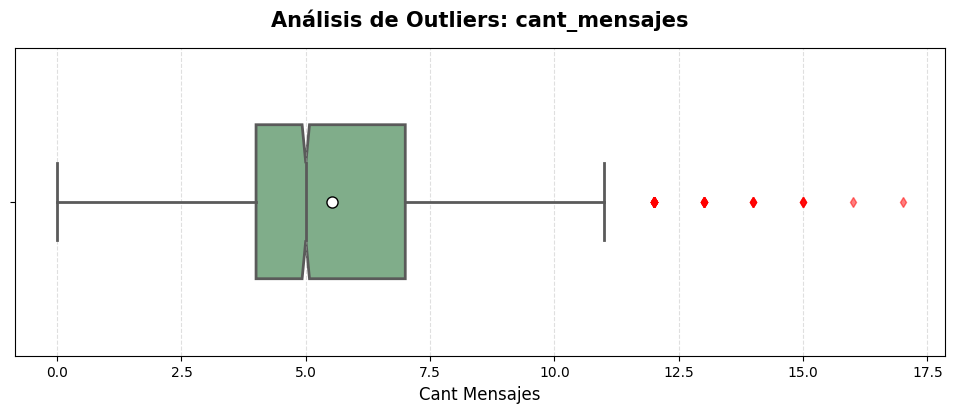

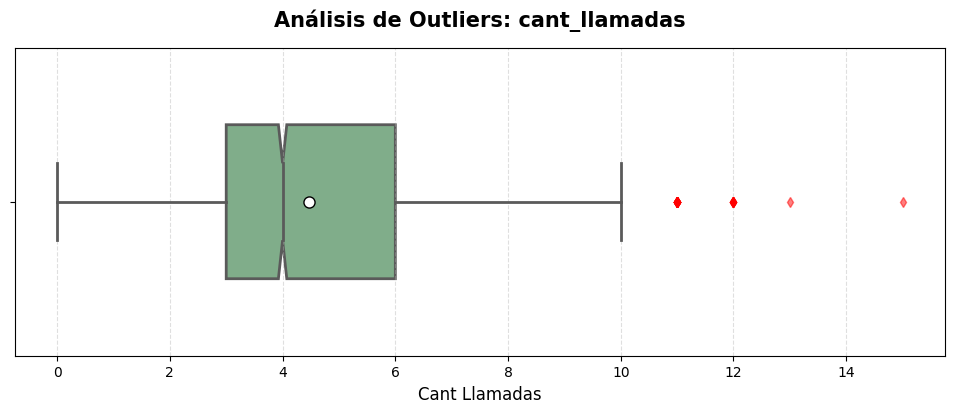

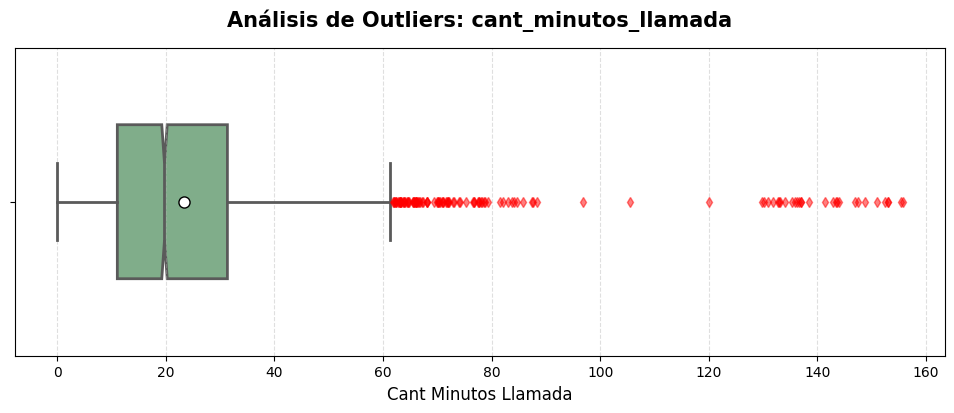

In [ ]:

# Visualizando usando BoxPlot
columnas_analizar = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# 2. Creamos el bucle for
for col in columnas_analizar:
    # Creamos una nueva figura para cada gráfico
    plt.figure(figsize=(12, 4))


    sns.boxplot(data=user_profile, x=col,
                color='#79B486',
                linewidth=2,
                width=0.5,
                notch=True,
                showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                flierprops={"marker": "d", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5})

    plt.title(f'Análisis de Outliers: {col}', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)

    # Añadimos una cuadrícula sutil solo en el eje X para medir mejor los rangos
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.show()


💡Insights:
- Age: No presenta Outliers, ya que se corrigio está columna imputando con la mediana
- cant_mensajes: Presenta outliers sesgada a la derecha y se observa que llega a un punto cercano de 17.5 mensajes enviados
- cant_llamadas: Presenta outliers sesgada a la derecha y se observa que llega a más de 14 llamadas realizadas
- cant_minutos_llamada: Presenta outliers sesgada a la derecha y se observa que llega a un punto cercano que una llamada finalice después de los 150 minutos o más

### 5.2 Identificación de Outliers

Objetivo:
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

Instrucciones:  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
cols_con_outliers = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in cols_con_outliers:
    # 1. Calculamos los cuartiles
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    # 2. Calculamos el IQR
    IQR = Q3 - Q1

    # 3. Calculamos el límite superior (la valla)
    limite_superior = Q3 + 1.5 * IQR

    print(f"--- Columna: {col} ---")
    print(f"Límite superior: {limite_superior}")

    # 4. ¿Cuántos outliers hay?
    outliers = user_profile[user_profile[col] > limite_superior]
    print(f"Cantidad de outliers detectados: {len(outliers)}")
    print("\n")

--- Columna: cant_mensajes ---
Límite superior: 11.5
Cantidad de outliers detectados: 45


--- Columna: cant_llamadas ---
Límite superior: 10.5
Cantidad de outliers detectados: 30


--- Columna: cant_minutos_llamada ---
Límite superior: 61.760000000000005
Cantidad de outliers detectados: 110




In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[cols_con_outliers].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.518380,4.471618,23.288867
std,2.358046,2.142878,18.161719
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.085000
50%,5.000000,4.000000,19.770000
75%,7.000000,6.000000,31.355000
max,17.000000,15.000000,155.690000


In [ ]:
# Filtramos los outliers para crear el perfil de usuario limpio
user_profile_clean = user_profile[
    (user_profile['cant_mensajes'] <= 11.5) &
    (user_profile['cant_llamadas'] <= 10.5) &
    (user_profile['cant_minutos_llamada'] <= 61.7)
].copy()

print(f"Usuarios después de la limpieza: {len(user_profile_clean)}")

Usuarios después de la limpieza: 3826


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
- **No voy a mantener los outliers para que no afecten los valores extremos que no representan la tendencia del consumo. El filtrado no busca ignorar clientes, sino estabilizar la varianza. Al trabajar con user_profile_clean, se garantiza que la desviación estándar sea menor, lo que nos da mayor potencia estadística para las pruebas de hipótesis.**

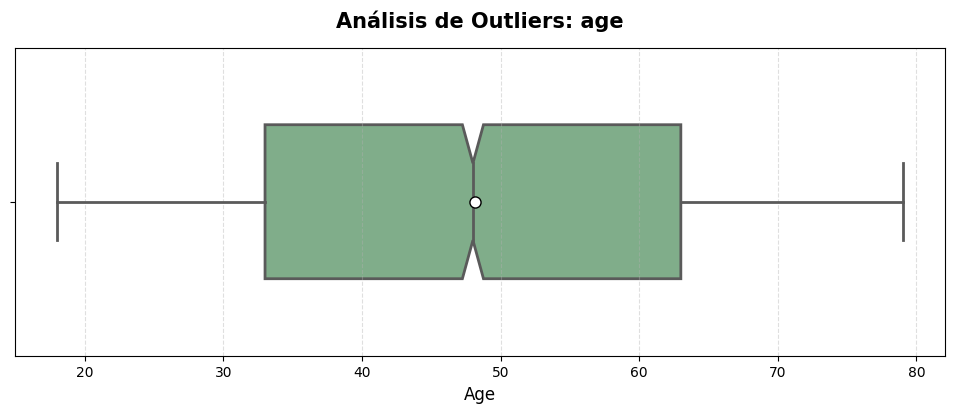

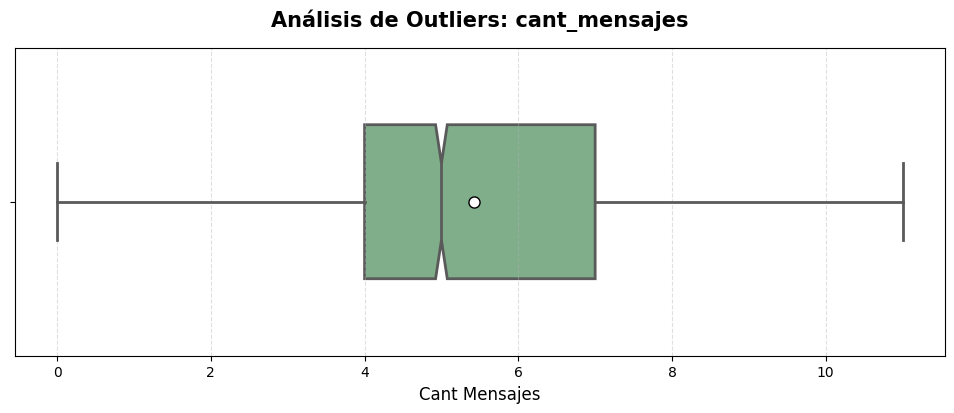

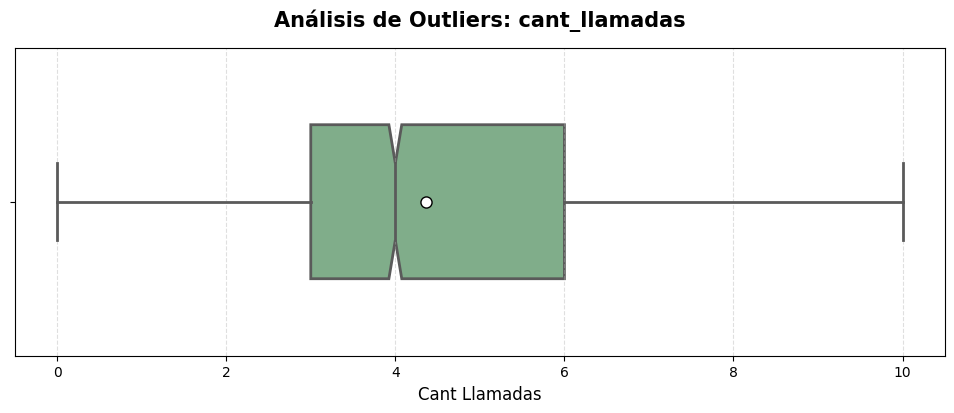

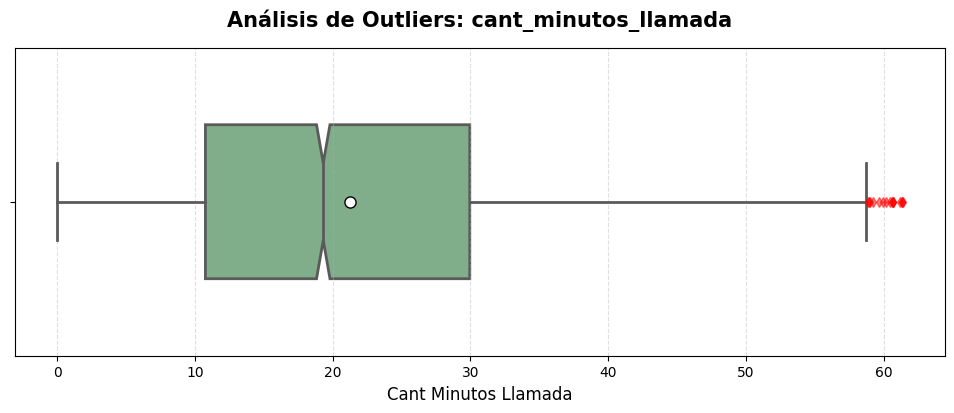

In [ ]:
# Visualizando usando BoxPlot sin valores atípicos
columnas_analizar = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

#Creamos el bucle for
for col in columnas_analizar:
    # Creamos una nueva figura para cada gráfico
    plt.figure(figsize=(12, 4))


    sns.boxplot(data=user_profile_clean, x=col,
                color='#79B486',
                linewidth=2,
                width=0.5,
                notch=True,
                showmeans=True,
                meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                flierprops={"marker": "d", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5})

    plt.title(f'Análisis de Outliers: {col}', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)

    # Añadimos una cuadrícula sutil solo en el eje X para medir mejor los rangos
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.show()

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    llamada = row["cant_llamadas"]
    mensaje = row["cant_mensajes"]
    if llamada < 5 and mensaje < 5:
        return "Bajo Uso"
    elif llamada < 10 and mensaje < 10:
        return "Uso Medio"
    else:
        return "Alto Uso"

user_profile_clean["grupo_uso"] = user_profile_clean.apply(clasificar_uso, axis=1)


In [ ]:
# verificar cambios
user_profile_clean.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso Medio
1,10001,Mateo,Torres,53.0,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto Uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso Medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto Uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo Uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row["age"]
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile_clean["grupo_edad"] = user_profile_clean.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile_clean.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,Unknown,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto Uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto Uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo Uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

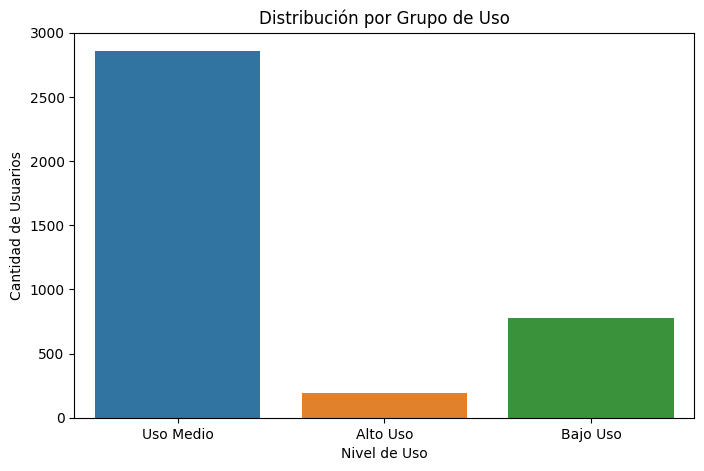

In [ ]:
# Visualización de los segmentos por uso

plt.figure(figsize=(8, 5))

sns.countplot(data=user_profile_clean, x='grupo_uso')

# 3. Títulos limpios
plt.title('Distribución por Grupo de Uso')
plt.xlabel('Nivel de Uso')
plt.ylabel('Cantidad de Usuarios')

# 4. Mostrar
plt.show()


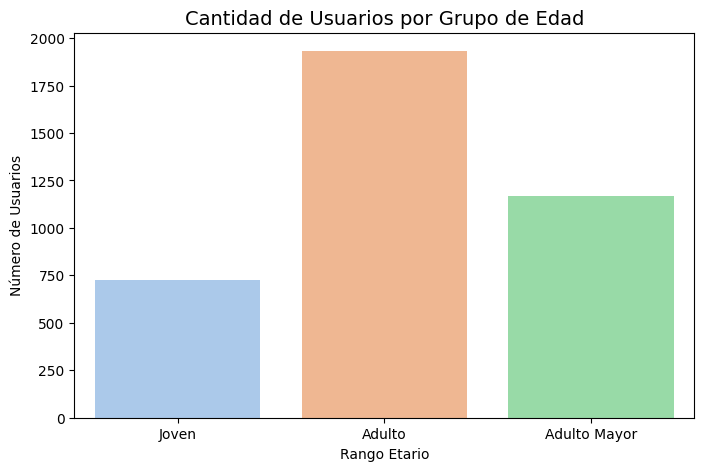

In [ ]:
# 1. Tamaño de la figura
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile_clean,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette='pastel'
)

# 3. Títulos y etiquetas
plt.title('Cantidad de Usuarios por Grupo de Edad', fontsize=14)
plt.xlabel('Rango Etario')
plt.ylabel('Número de Usuarios')

# 4. Mostrar
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los datos presentaban ligeros problemas con algunas columnas en las cuales se presentaban Sentinels como **-999, 999, ?, NA `NAN`, espacios en blanco entre otros**. La cantidad era entre el 10 al 15% de estos datos con sentinelas, entre algunas de esas columnas se presento en el dataframe de **users** `age`, `reg_date` y `city`, otros presentaban valores nulos pero en este apartado se llego a la conclusión de que esto sucede ya que así manejan quienes cancelaron el plan, la duración de una llamada o la longitud de un mensaje de texto

🔍 **Segmentos por Edad**
- Se identificaron tres tipos de clientes por su edad, Joven, Adulto y Adulto Mayor, el que predomina en este apartado se observa que es el adulto, ya que es el grupo con mayor estabilidad economica y son aquellos que usan el servicio de forma constante

📊 **Segmentos por Nivel de Uso**
- Se identificaron tres tipos de Nivel, Bajo Uso, Uso Medio y el Alto uso, el Uso Medio es masiva, superando los 2500 usuarios. Aunque no son los que más consumen individualmente, son los que mantienen a flote la empresa porque representan a la gran mayoría de la base de clientes

**Outliers, ¿qué implicaria?**
- Minutos de Llamada: Encontramos gente hablando hasta 155 minutos, cuando el usuario común no pasa de los 60. Estos son nuestros clientes más fieles o gente que usa el plan para trabajo/negocios. Son valiosos, pero si no tienen un plan ilimitado, pueden representar un riesgo de queja por costos altos o, por el contrario, ser candidatos perfectos para un plan Premium
- Llamadas largas: O en esta ocasión podemos observar esa cantidad de minutos mayor a 60 minutos o hasta más sea por un usuario que se este comunicando con un familiar, pareja o amigo, para poder ofrecerle minutos ilimitados

💡 **Recomendaciones**
- Plan "Voz Total" para Adultos: Como vimos que los Adultos son el grupo más grande y tienen un uso de llamadas constante, la recomendación es un plan que priorice minutos ilimitados. Es un segmento que prefiere llamar antes que textear.
- Upgrade para el "Alto Uso": A los que identificamos en la barra de Alto Uso, ConnectaTel debería enviarles una oferta automática para el plan Premium. Si ya están rozando los límites del básico, son los clientes más fáciles de convencer para que paguen un poco más por tranquilidad.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`